# Data Preprocessing for scDiffusion

In [1]:
import scanpy as sc
import os
import argparse

## Configuration

In [2]:
# Input data path
data_dir = "/home/suzuki/Projects/scDiffusion/data_preparation/data/Pancreas/endocrinogenesis_day15.h5ad"


preprocessed_path="/home/suzuki/Projects/scDiffusion/work/20260123_pancreas/pancreas_preprocessed_20260123.h5ad"

## Load Data

In [3]:
print("Loading h5ad file...")
adata = sc.read_h5ad(data_dir)
print(f"Original data shape: {adata.shape}")

Loading h5ad file...


Original data shape: (3696, 27998)


/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/anndata/compat/__init__.py:232: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/anndata/compat/__init__.py:232: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


## Filtering

In [4]:
# Apply filtering
print("Applying filtering...")
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)
print(f"Data shape after filtering: {adata.shape}")

Applying filtering...


Data shape after filtering: (3696, 15737)


## Normalization and Log Transformation

In [5]:
# Apply normalization and log transformation
print("Applying normalization and log transformation...")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print("Normalization and log transformation completed")

Applying normalization and log transformation...
Normalization and log transformation completed


## Highly Variable Genes (HVG) Selection

In [6]:
# --- HVG selection ---
print("Selecting highly variable genes...")
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1024,         # HVG 1024 genes (20251218 version)
    # flavor="seurat_v3",     # Optional: specify flavor if needed (e.g., 'seurat_v3')
    subset=True,               # Subset to HVG only
    inplace=True
)
print(f"Number of HVG kept: {adata.n_vars}")

Selecting highly variable genes...


/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


Number of HVG kept: 1024


## Z-score Normalization

In [7]:
# Apply z-score normalization
print("Applying z-score normalization...")
sc.pp.scale(adata, zero_center=True)
print("Z-score normalization completed")

Applying z-score normalization...
Z-score normalization completed


## Rename

In [16]:
adata.obs.rename(columns={"clusters": "celltype"}, inplace=True)

In [27]:
adata.var["gene_name"] = adata.var_names

## Save Preprocessed Data

In [30]:
# Save preprocessed data
print(f"Saving preprocessed data to: {preprocessed_path}")
adata.write(preprocessed_path)
print("Preprocessing completed successfully!")

Saving preprocessed data to: /home/suzuki/Projects/scDiffusion/work/20260123_pancreas/pancreas_preprocessed_20260123.h5ad
Preprocessing completed successfully!


## Verification

In [28]:
# Verify the saved data
print("\n=== Verification ===")
print(f"Final data shape: {adata.shape}")
print(f"adata.var columns: {list(adata.var.columns)}")
print(f"'gene_name' column exists in adata.var: {'gene_name' in adata.var.columns}")
print(f"adata.obs columns: {list(adata.obs.columns)}")
print(f"'celltype' column exists in adata.obs: {'celltype' in adata.obs.columns}")
print(f"adata.n_vars (number of genes): {adata.n_vars}")
print(f"adata.n_obs (number of cells): {adata.n_obs}")


=== Verification ===
Final data shape: (3696, 1024)
adata.var columns: ['highly_variable_genes', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_name']
'gene_name' column exists in adata.var: True
adata.obs columns: ['clusters_coarse', 'celltype', 'S_score', 'G2M_score', 'n_genes']
'celltype' column exists in adata.obs: True
adata.n_vars (number of genes): 1024
adata.n_obs (number of cells): 3696


# UMAP確認

In [10]:
import matplotlib.pyplot as plt
# ノートブックのパラメータに準拠
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata)

In [29]:
adata.var

,highly_variable_genes,n_cells,highly_variable,means,dispersions,dispersions_norm,mean,std,gene_name
index,,,,,,,,,
Mcm3,True,843,True,0.423014,0.993647,1.923305,0.255243,0.502868,Mcm3
Fhl2,True,586,True,0.352485,1.297112,3.448328,0.192370,0.468121,Fhl2
Akr1cl,True,403,True,0.208814,1.158521,3.086307,0.114338,0.352095,Akr1cl
Mreg,False,201,True,0.115017,1.030383,2.440215,0.061225,0.264358,Mreg
Igfbp5,True,481,True,0.221294,0.883042,1.697295,0.130949,0.357848,Igfbp5
...,...,...,...,...,...,...,...,...,...
Ubqln2,True,2245,True,1.420085,1.705817,1.515843,0.976868,0.931146,Ubqln2
Cypt3,True,26,True,0.020157,1.620132,5.413835,0.008599,0.109552,Cypt3
Map3k15,True,534,True,0.277833,0.906761,1.486671,0.162358,0.409101,Map3k15


/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/suzuki/.conda/envs/scdiffusion_jupyter/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


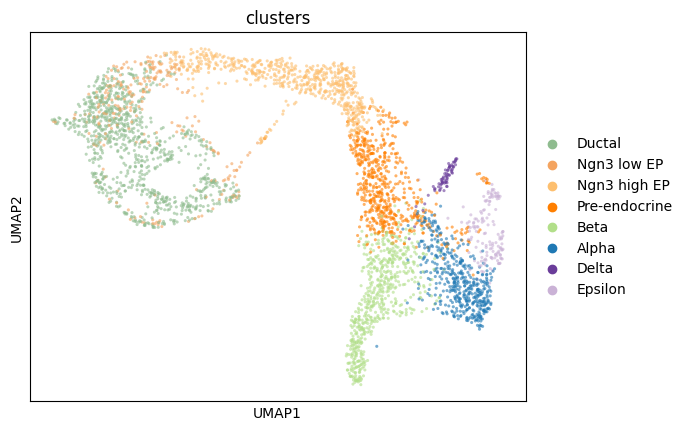

In [13]:
sc.pl.umap(adata, color="clusters", 
            size=20, alpha=0.6)